# Systematic Cross-Asset Skewness Strategy (v2, Modular)

This notebook is a **clean execution canvas**: each section orchestrates one stage of the strategy while heavy logic lives in reusable Python modules under `experiments/cam_skewness_core/`.

The workflow follows an institutional research process:
1. Universe and data quality checks
2. Signal engineering and exploratory diagnostics
3. Portfolio construction and execution mapping
4. Class/global performance and risk diagnostics
5. Attribution and practical implementation checks


## 1. Environment and Modular Imports

This section loads all reusable building blocks. The notebook stays concise by calling tested functions instead of embedding long implementation blocks.


In [1]:
import warnings
import sys
from pathlib import Path

# Make project imports robust regardless of where the notebook kernel starts.
PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "experiments").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "experiments").exists():
    raise RuntimeError(f"Could not locate project root from cwd={Path.cwd()}")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from IPython.display import display

from experiments.cam_skewness_core.config import (
    LOOKBACK,
    HISTORY_DAYS,
    VOL_TARGET,
    UNIVERSE,
    FACTOR_TICKERS,
    SAMPLE_TICKERS,
    SAMPLE_WEIGHT_TICKERS,
)
from experiments.cam_skewness_core.data_loader import (
    LOADER_VERSION,
    load_universe_yf,
    universe_summary,
    data_quality_summary,
)
from experiments.cam_skewness_core.signal import (
    add_skew_features,
    skew_distribution_by_class,
    build_monthly_signal_table,
    add_rank_weights,
)
from experiments.cam_skewness_core.backtest import (
    apply_monthly_weights_to_daily,
    compute_asset_class_returns,
    compute_global_factor,
    weight_sanity_checks,
    monthly_turnover,
)
from experiments.cam_skewness_core.analytics import (
    run_asset_class_alpha_beta,
    run_equity_factor_regression,
    build_coef_table,
    performance_table,
)
from experiments.cam_skewness_core.plots import (
    plot_sample_returns_and_skew,
    plot_skew_distribution_box,
    plot_latest_skew_and_weights,
    plot_sample_weight_history,
    plot_asset_class_cum_returns,
    plot_asset_class_strategy_vs_market,
    plot_global_factor,
    plot_global_drawdown,
    plot_turnover_by_class,
)

warnings.filterwarnings('ignore', category=FutureWarning)
pd.options.display.float_format = '{:.6f}'.format
plt.rcParams['figure.dpi'] = 120
print('Project root on path:', PROJECT_ROOT)



Project root on path: /Users/atheeshkrishnan/AK/DEV/cross-asset-moments


## 2. Strategy Definition and Universe Integrity

This section fixes core hyperparameters and validates universe structure. From a PM perspective, this is where you lock your research contract: horizon, risk target, and investable set.


In [2]:
print('LOOKBACK:', LOOKBACK)
print('HISTORY_DAYS:', HISTORY_DAYS)
print('VOL_TARGET:', VOL_TARGET)
print('Loader:', LOADER_VERSION)

univ = universe_summary(UNIVERSE)
display(univ)
print('Total listed tickers:', int(univ['TickersListed'].sum()))
print('Total unique tickers:', int(univ['TickersUnique'].sum()))


LOOKBACK: 256
HISTORY_DAYS: 3650
VOL_TARGET: 0.1
Loader: yf_loader_v4_2026_03_18


,AssetClass,TickersListed,TickersUnique,Duplicates
0,Ccy,7,7,0
1,Commodities,7,7,0
2,Equity,25,24,1
3,FI,15,15,0
4,Other,5,5,0


Total listed tickers: 59
Total unique tickers: 58


## 3. Data Ingestion and Pre-Trade Data QA

The objective here is not just to pull prices, but to prove data reliability before signal generation: schema validity, failure transparency, and coverage diagnostics.


In [3]:
all_data, failures = load_universe_yf(UNIVERSE, HISTORY_DAYS)
print('all_data shape:', all_data.shape)
print('columns:', list(all_data.columns))

if all_data.empty:
    raise RuntimeError('No data loaded from yfinance. Check internet access and package version.')
if 'Ticker' not in all_data.columns:
    raise RuntimeError(f"Schema mismatch after load: {list(all_data.columns)}")

display(all_data.head())

if not failures.empty:
    print(f'Failed tickers: {len(failures)}')
    display(failures.head(20))
else:
    print('No ticker failures during load.')


all_data shape: (145754, 7)
columns: ['Date', 'Ticker', 'close', 'open', 'NextOpen', 'LogReturn', 'AssetClass']


,Date,Ticker,close,open,NextOpen,LogReturn,AssetClass
0,2016-03-21,AGG,83.407745,110.059998,110.269997,NaN,FI
1,2016-03-22,AGG,83.354630,110.269997,109.959999,-0.000637,FI
2,2016-03-23,AGG,83.536736,109.959999,110.290001,0.002182,FI
3,2016-03-24,AGG,83.544327,110.290001,110.150002,0.000091,FI
4,2016-03-28,AGG,83.605011,110.150002,110.349998,0.000726,FI


No ticker failures during load.


### 3.1 Data Coverage Diagnostics (Trader-Facing)

These diagnostics answer practical questions:
- How balanced is history across assets?
- Are any symbols under-covered or sparse?
- Does each asset class have stable breadth over time?


,Ticker,AssetClass,StartDate,EndDate,Obs,MissingReturnPct
0,FXA,Ccy,2016-03-21,2026-03-18,2513,0.039793
1,FXB,Ccy,2016-03-21,2026-03-18,2513,0.039793
2,FXC,Ccy,2016-03-21,2026-03-18,2513,0.039793
3,FXE,Ccy,2016-03-21,2026-03-18,2513,0.039793
4,FXF,Ccy,2016-03-21,2026-03-18,2513,0.039793
5,FXY,Ccy,2016-03-21,2026-03-18,2513,0.039793
6,UUP,Ccy,2016-03-21,2026-03-18,2513,0.039793
7,DBA,Commodities,2016-03-21,2026-03-18,2513,0.039793
8,GLD,Commodities,2016-03-21,2026-03-18,2513,0.039793
9,GSG,Commodities,2016-03-21,2026-03-18,2513,0.039793


,AssetClass,Tickers,Obs,Start,End
0,Ccy,7,17591,2016-03-21,2026-03-18
1,Commodities,7,17591,2016-03-21,2026-03-18
2,Equity,24,60312,2016-03-21,2026-03-18
3,FI,15,37695,2016-03-21,2026-03-18
4,Other,5,12565,2016-03-21,2026-03-18


,AssetClass,ExpectedTickers,MinActive,MedianActive,MaxActive,MinUtilizationPct,MedianUtilizationPct,MaxUtilizationPct,FullCoveragePct
0,Ccy,7,7,7.000000,7,100.000000,100.000000,100.000000,100.000000
1,Commodities,7,7,7.000000,7,100.000000,100.000000,100.000000,100.000000
2,Equity,24,24,24.000000,24,100.000000,100.000000,100.000000,100.000000
3,FI,15,15,15.000000,15,100.000000,100.000000,100.000000,100.000000
4,Other,5,5,5.000000,5,100.000000,100.000000,100.000000,100.000000


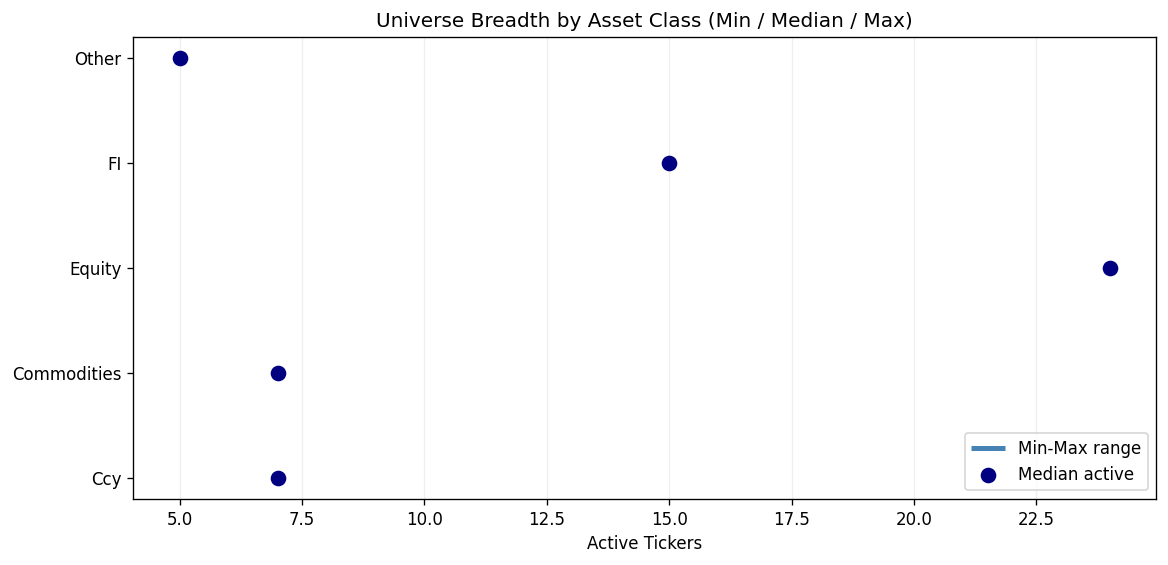

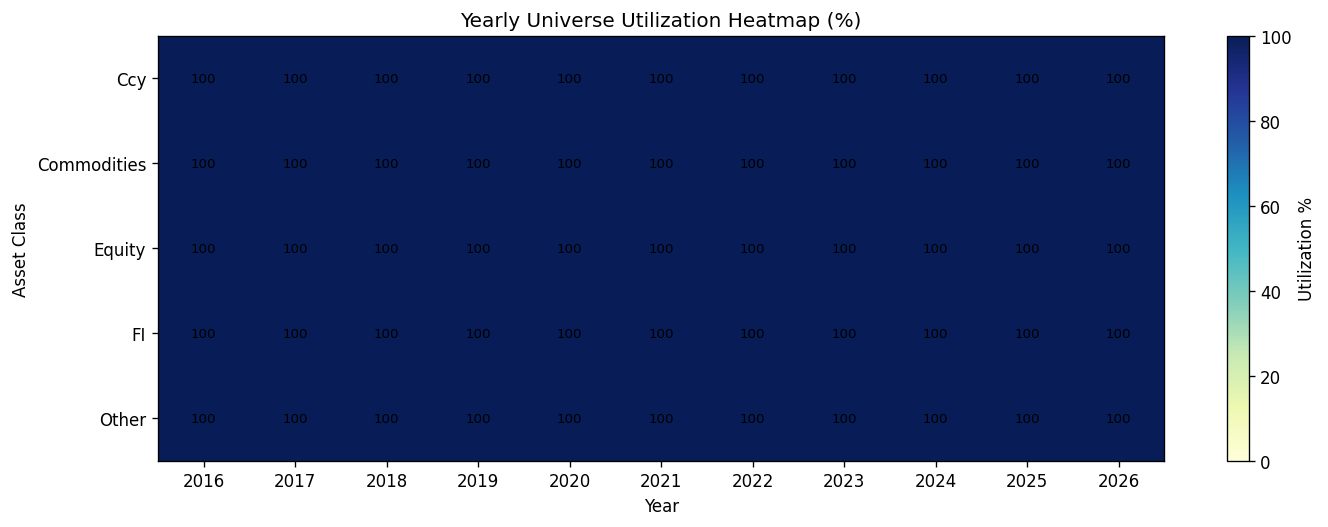

In [4]:
quality = data_quality_summary(all_data)
display(quality.head(15))

class_snapshot = all_data.groupby('AssetClass', as_index=False).agg(
    Tickers=('Ticker', 'nunique'),
    Obs=('Date', 'count'),
    Start=('Date', 'min'),
    End=('Date', 'max'),
)
display(class_snapshot.sort_values('AssetClass'))

# Better breadth diagnostics for mostly-stable universes:
# 1) summary stats by class
# 2) min/median/max utilization plot
# 3) yearly utilization heatmap
breadth = all_data.groupby(['Date', 'AssetClass'])['Ticker'].nunique().reset_index(name='ActiveTickers')
expected = univ[['AssetClass', 'TickersUnique']].rename(columns={'TickersUnique': 'ExpectedTickers'})
breadth = breadth.merge(expected, on='AssetClass', how='left')
breadth['UtilizationPct'] = 100.0 * breadth['ActiveTickers'] / breadth['ExpectedTickers']

breadth_stats = breadth.groupby('AssetClass', as_index=False).agg(
    ExpectedTickers=('ExpectedTickers', 'first'),
    MinActive=('ActiveTickers', 'min'),
    MedianActive=('ActiveTickers', 'median'),
    MaxActive=('ActiveTickers', 'max'),
    MinUtilizationPct=('UtilizationPct', 'min'),
    MedianUtilizationPct=('UtilizationPct', 'median'),
    MaxUtilizationPct=('UtilizationPct', 'max'),
    FullCoveragePct=('UtilizationPct', lambda s: 100.0 * (s == 100.0).mean()),
)

breadth_stats = breadth_stats.sort_values('AssetClass').reset_index(drop=True)
display(breadth_stats.round(2))

# Plot A: min/median/max active tickers by class
plot_df = breadth_stats.copy()
y = np.arange(len(plot_df))

plt.figure(figsize=(11, 5))
plt.hlines(y=y, xmin=plot_df['MinActive'], xmax=plot_df['MaxActive'], color='steelblue', linewidth=3, label='Min-Max range')
plt.scatter(plot_df['MedianActive'], y, color='navy', s=70, zorder=3, label='Median active')
plt.yticks(y, plot_df['AssetClass'])
plt.xlabel('Active Tickers')
plt.title('Universe Breadth by Asset Class (Min / Median / Max)')
plt.legend(loc='lower right')
plt.grid(axis='x', alpha=0.2)
plt.show()

# Plot B: yearly average utilization heatmap (Active / Expected)
breadth['Year'] = breadth['Date'].dt.year
heat = breadth.groupby(['AssetClass', 'Year'])['UtilizationPct'].mean().unstack('Year').sort_index()

fig, ax = plt.subplots(figsize=(12, 4.5))
im = ax.imshow(heat.values, aspect='auto', vmin=0, vmax=100, cmap='YlGnBu')
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)
ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(heat.columns, rotation=0)
ax.set_title('Yearly Universe Utilization Heatmap (%)')
ax.set_xlabel('Year')
ax.set_ylabel('Asset Class')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Utilization %')

# annotate cells for readability
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        val = heat.iat[i, j]
        ax.text(j, i, f'{val:.0f}', ha='center', va='center', color='black', fontsize=8)

plt.tight_layout()
plt.show()


## 4. Signal Engineering and EDA

This section builds the rolling skew signal and pressure-tests its behavior. The focus is both statistical correctness and interpretability under real market regimes.


In [5]:
all_data = add_skew_features(all_data, LOOKBACK)
print('signal-ready shape:', all_data.shape)
display(all_data.head())


signal-ready shape: (116116, 11)


,Date,Ticker,close,open,NextOpen,LogReturn,AssetClass,Avg,Dev,SkewDay,Skew
0,2018-04-02,AGG,85.201813,106.900002,106.820000,-0.001000,FI,0.000048,0.001637,-0.262297,0.072305
1,2018-04-03,AGG,85.106148,106.820000,106.900002,-0.001123,FI,0.000034,0.001632,-0.356847,0.064928
2,2018-04-04,AGG,85.138062,106.900002,106.709999,0.000375,FI,0.000045,0.001626,0.008362,0.070825
3,2018-04-05,AGG,85.018456,106.709999,106.889999,-0.001406,FI,0.000031,0.001623,-0.693834,0.063424
4,2018-04-06,AGG,85.209763,106.889999,106.830002,0.002248,FI,0.000047,0.001624,2.487478,0.076128


,AssetClass,count,mean,std,min,median,max
0,Ccy,14014,0.069258,0.714292,-2.656941,0.000983,3.493066
1,Commodities,14014,-0.530123,1.218517,-6.655256,-0.164199,2.521456
2,Equity,48048,-1.020102,2.013327,-12.354135,-0.290402,3.268492
3,FI,30030,-1.230484,3.444855,-18.939897,-0.068773,4.219431
4,Other,10010,-1.431359,2.972319,-13.224359,-0.468196,0.709012


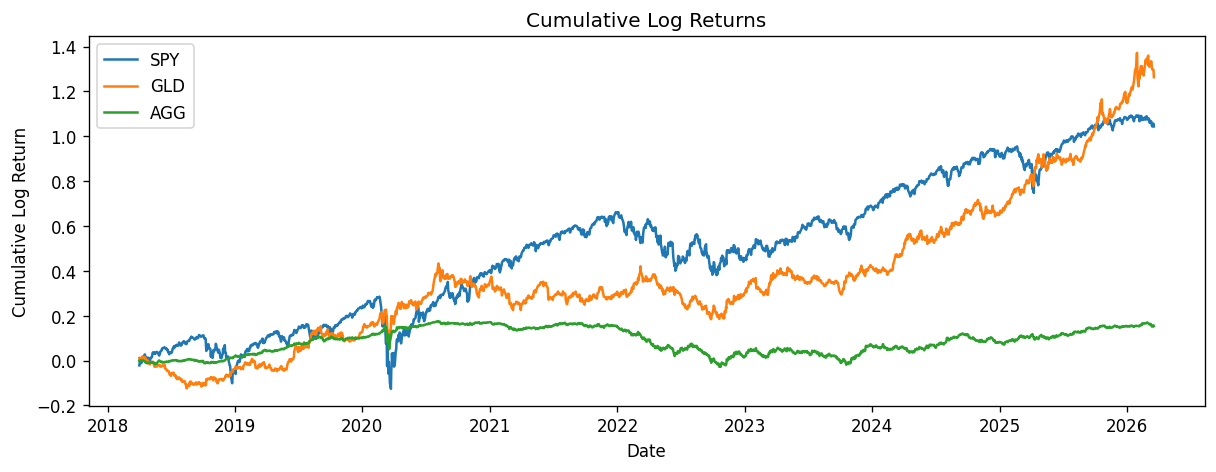

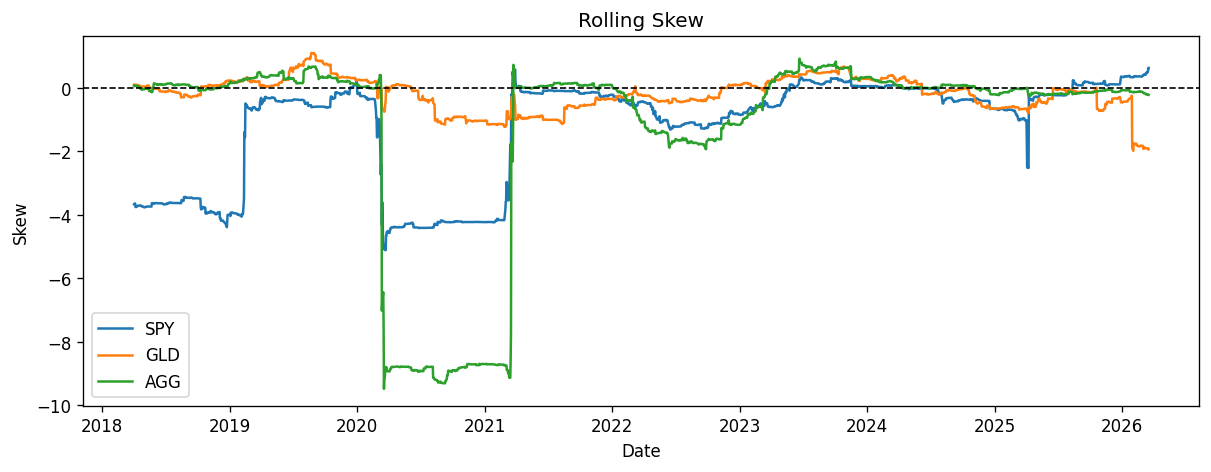

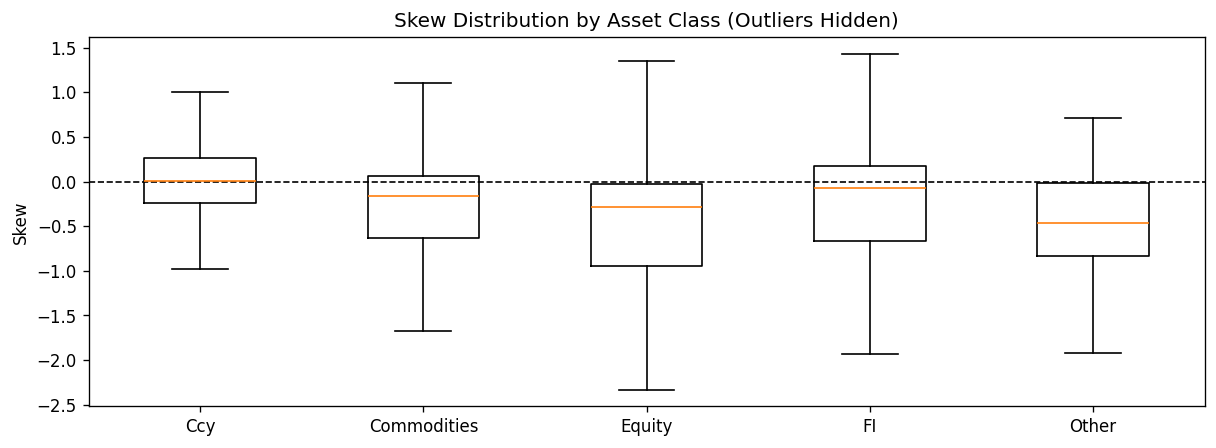

In [6]:
dist_tbl = skew_distribution_by_class(all_data)
display(dist_tbl)
plot_sample_returns_and_skew(all_data, SAMPLE_TICKERS)
plot_skew_distribution_box(all_data)


## 5. Portfolio Construction and Execution Mapping

This section converts signal into tradable weights:
- end-of-month signal extraction
- next-day activation (anti-look-ahead)
- long-short normalization within each asset class
- daily forward-fill of live weights


In [7]:
monthly_vals = build_monthly_signal_table(all_data)
monthly_vals = add_rank_weights(monthly_vals)

display(monthly_vals.head())

latest_cross_section = monthly_vals.sort_values('Date').groupby(['Date', 'AssetClass']).size().tail(5)
display(latest_cross_section)


,Month,AssetClass,Ticker,Date,NextDate,EOMSkew,SkewWeightRaw,SkewWeight
0,2018-04-01,Ccy,FXA,2018-04-30,2018-05-01,-0.130043,3.000000,0.500000
1,2018-04-01,Ccy,FXB,2018-04-30,2018-05-01,0.068214,0.000000,0.000000
2,2018-04-01,Ccy,FXC,2018-04-30,2018-05-01,0.336666,-3.000000,-0.500000
3,2018-04-01,Ccy,FXE,2018-04-30,2018-05-01,0.154102,-2.000000,-0.333333
4,2018-04-01,Ccy,FXF,2018-04-30,2018-05-01,0.071202,-1.000000,-0.166667


Date        AssetClass 
2026-03-18  Ccy             7
            Commodities     7
            Equity         24
            FI             15
            Other           5
dtype: int64

### 5.1 Cross-Sectional Signal Inspection (v1-Inspired)

These views are trader-critical. They show whether the latest month-end cross-section is economically sensible:
- which commodities are extreme on skew,
- which names receive long vs short risk budget.


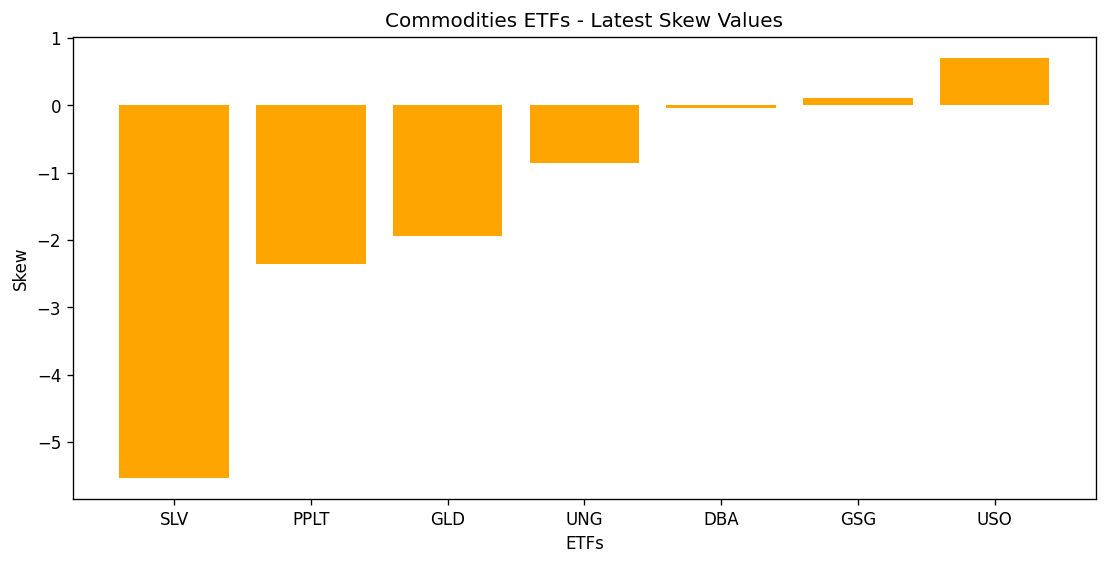

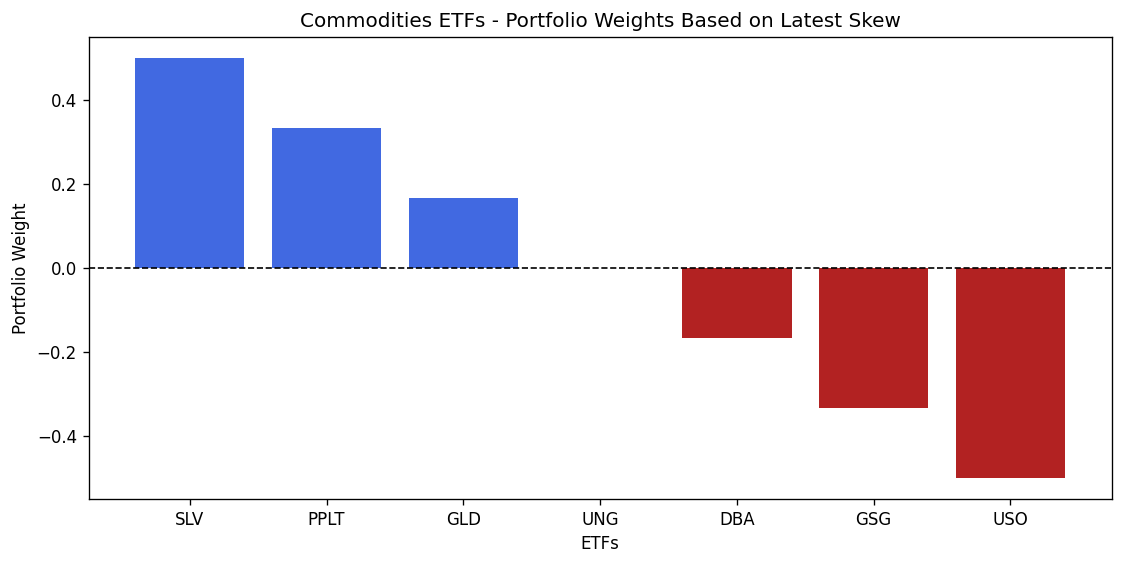

,Ticker,EOMSkew,SkewWeight
5521,SLV,-5.531879,0.500000
5520,PPLT,-2.365164,0.333333
5518,GLD,-1.935607,0.166667
5522,UNG,-0.854444,0.000000
5517,DBA,-0.035720,-0.166667
5519,GSG,0.105385,-0.333333
5523,USO,0.706995,-0.500000


In [8]:
commodity_snapshot = plot_latest_skew_and_weights(monthly_vals, asset_class='Commodities')
display(commodity_snapshot[['Ticker', 'EOMSkew', 'SkewWeight']])


### 5.2 Weight Path Diagnostics (v1-Inspired)

Weight trajectories for representative ETFs reveal regime shifts, signal instability, and implementation smoothness over time.


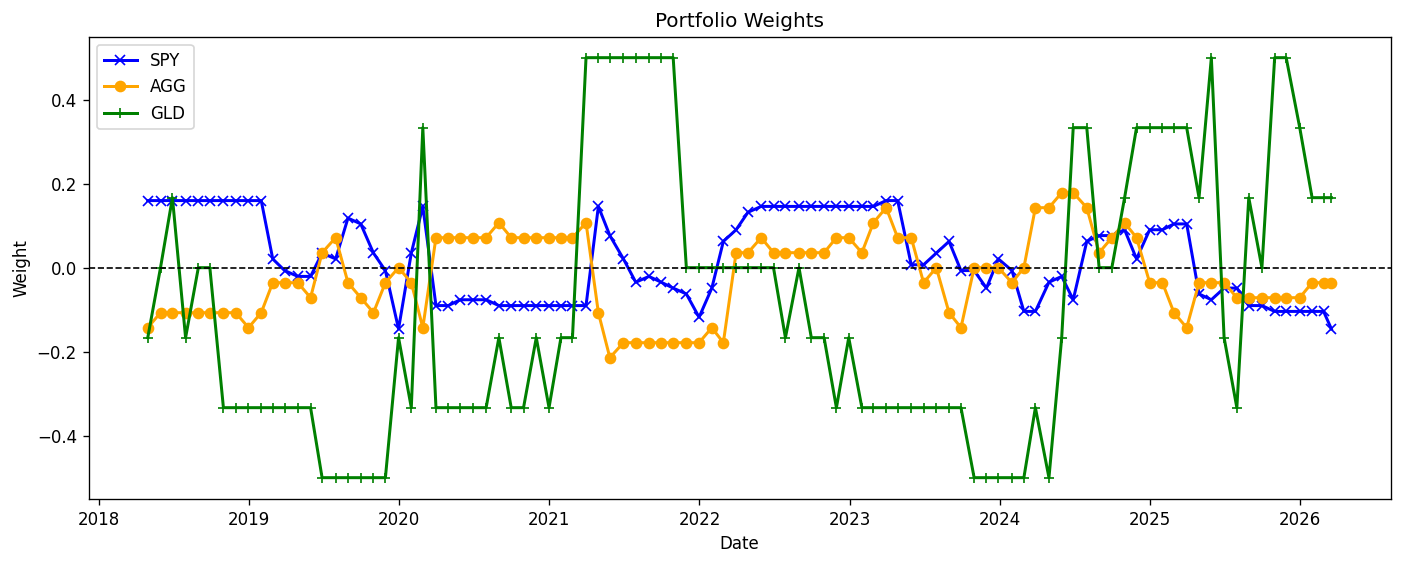

In [9]:
plot_sample_weight_history(monthly_vals, SAMPLE_WEIGHT_TICKERS)


In [10]:
all_data_weights = apply_monthly_weights_to_daily(all_data, monthly_vals)
asset_portfolios = compute_asset_class_returns(all_data_weights)

display(all_data_weights[['Date', 'Ticker', 'AssetClass', 'LogReturn', 'SkewWeight', 'SkewWeightFF']].head())
display(asset_portfolios.head())


,Date,Ticker,AssetClass,LogReturn,SkewWeight,SkewWeightFF
0,2018-04-02,AGG,FI,-0.001000,NaN,NaN
1,2018-04-03,AGG,FI,-0.001123,NaN,NaN
2,2018-04-04,AGG,FI,0.000375,NaN,NaN
3,2018-04-05,AGG,FI,-0.001406,NaN,NaN
4,2018-04-06,AGG,FI,0.002248,NaN,NaN


,Date,AssetClass,PortfolioReturn,MktReturn
0,2018-04-02,Ccy,0.000000,0.000217
1,2018-04-02,Commodities,0.000000,-0.005806
2,2018-04-02,Equity,0.000000,-0.016945
3,2018-04-02,FI,0.000000,-0.000229
4,2018-04-02,Other,0.000000,-0.014146


### 5.3 Asset-Class Performance Lens

We inspect strategy performance by sleeve first. This helps isolate where the signal is monetized and where it under-delivers before global aggregation.


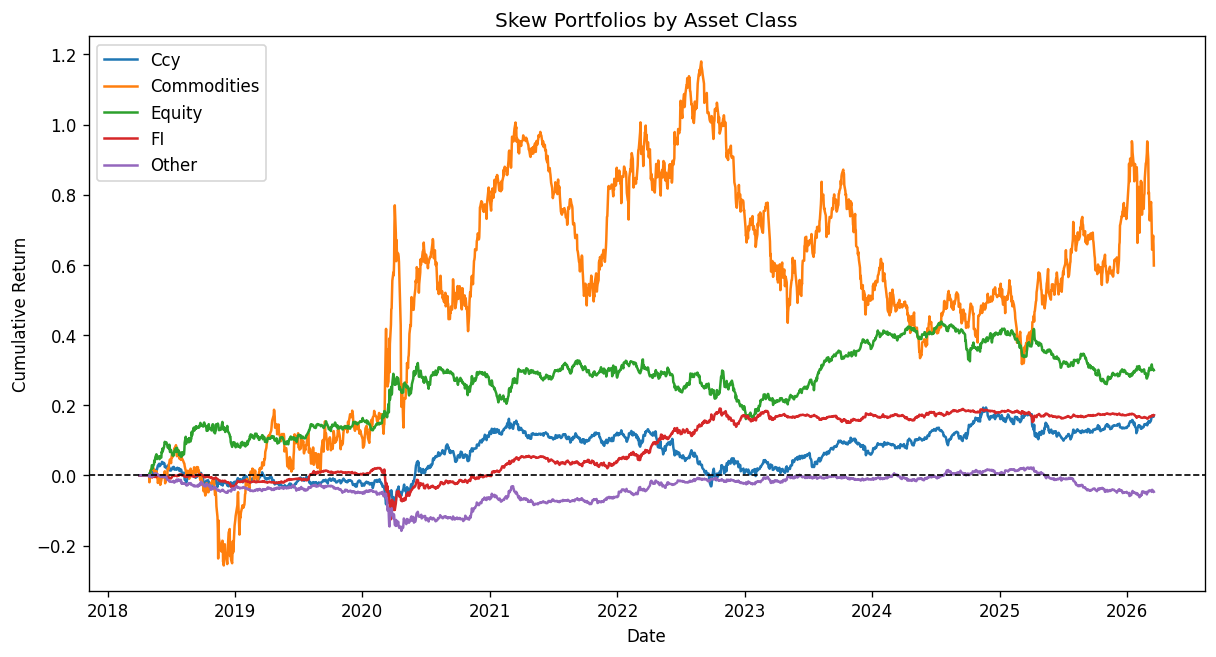

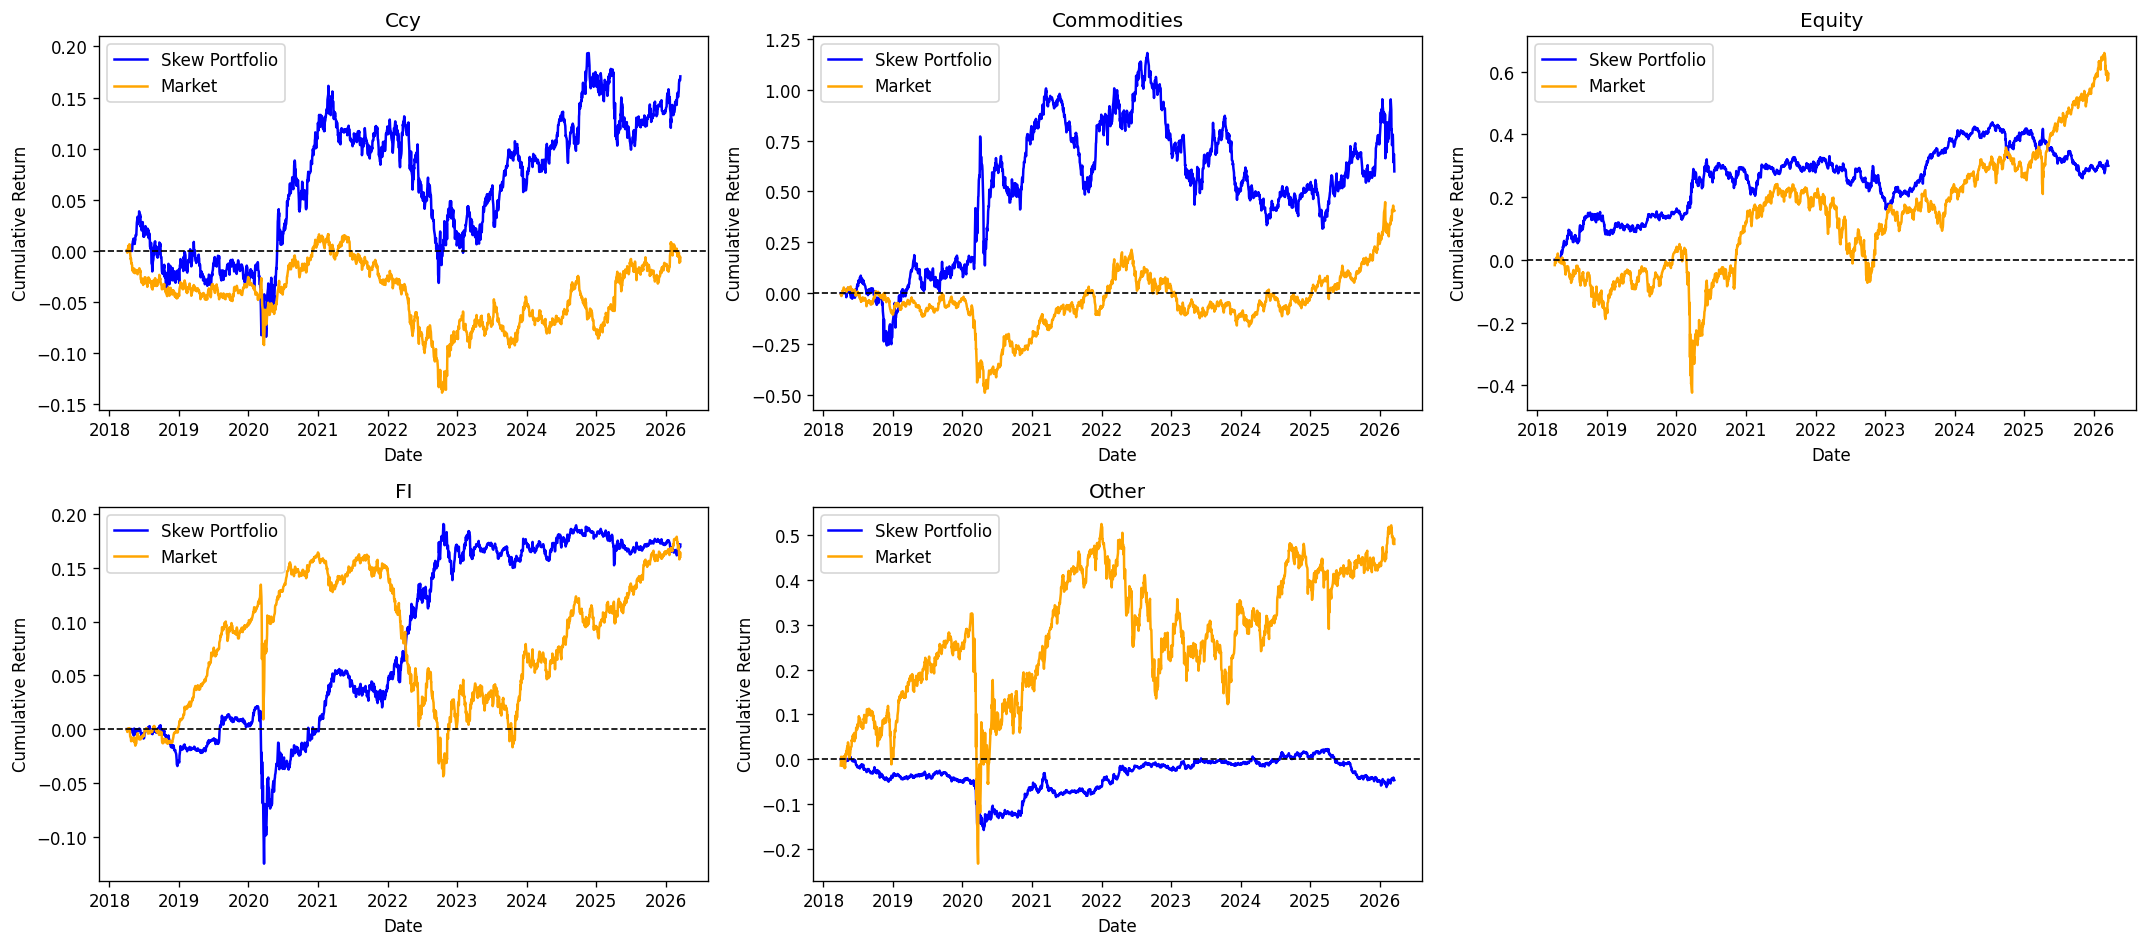

In [11]:
plot_asset_class_cum_returns(asset_portfolios)
plot_asset_class_strategy_vs_market(asset_portfolios, ncols=3)


## 6. Global Portfolio Construction and Risk Lens

Class sleeves are volatility-normalized to create a balanced global factor. We also include PM-style diagnostics: drawdown and compact performance stats.


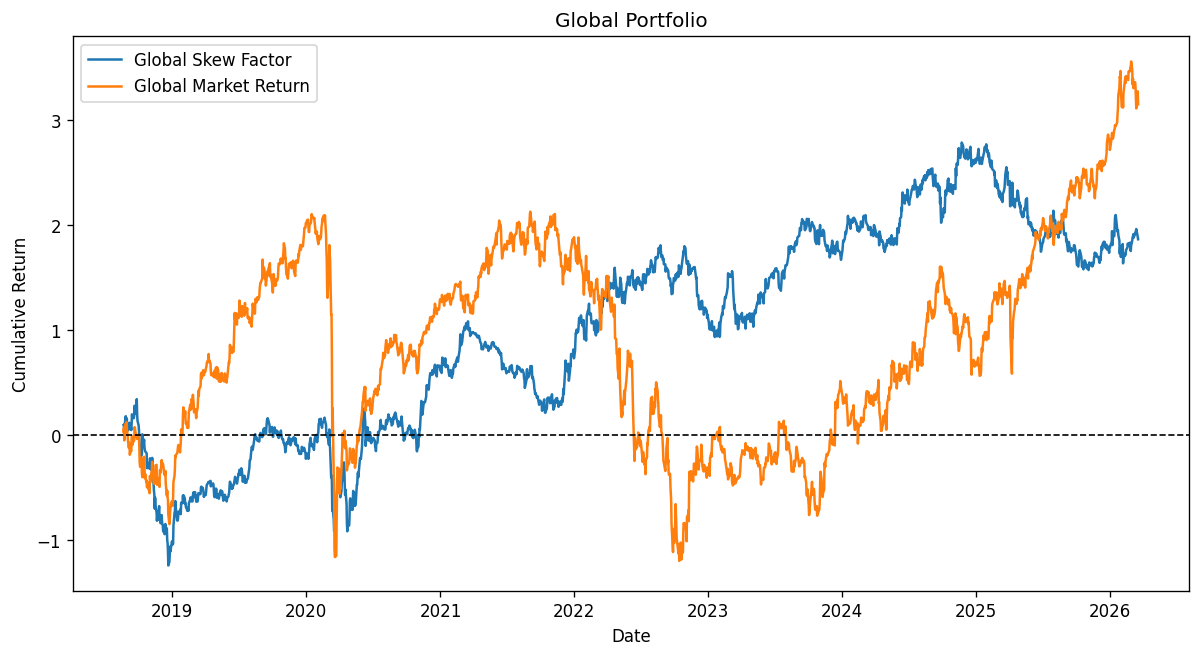

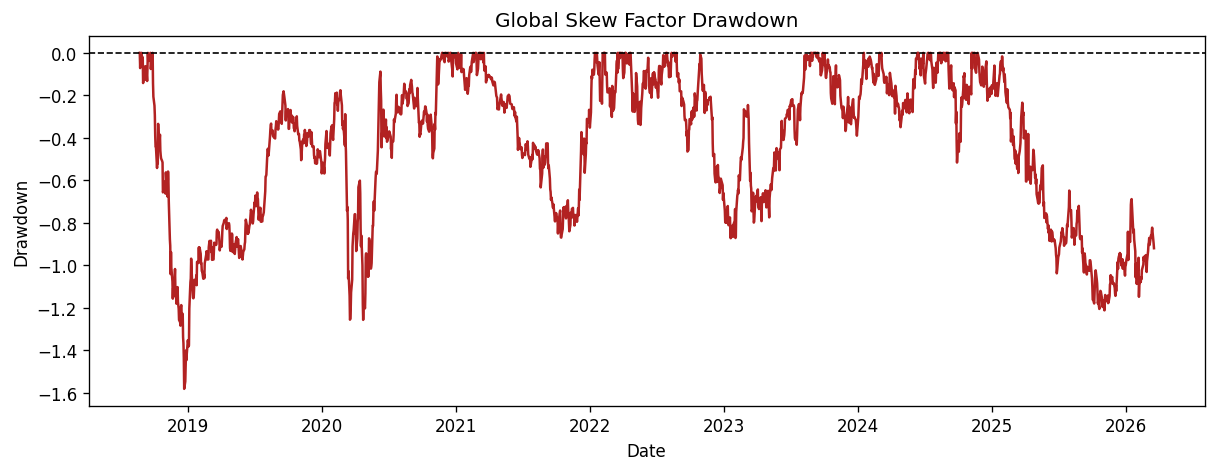

,Portfolio,Obs,AnnReturn,AnnVol,Sharpe
0,GlobalSkew,1903,0.246700,0.793100,0.311100
1,GlobalMarket,1903,0.416700,1.220200,0.341500


In [12]:
asset_portfolios_scaled, gcf = compute_global_factor(
    asset_portfolios,
    lookback=LOOKBACK,
    vol_target=VOL_TARGET,
    scale_market_with_strategy_vol=False,
)

plot_global_factor(gcf)
plot_global_drawdown(gcf)

global_perf = pd.DataFrame({
    'Portfolio': ['GlobalSkew', 'GlobalMarket'],
    'Obs': [len(gcf), len(gcf)],
    'AnnReturn': [gcf['Return'].mean() * 252, gcf['MktReturn'].mean() * 252],
    'AnnVol': [gcf['Return'].std(ddof=0) * np.sqrt(252), gcf['MktReturn'].std(ddof=0) * np.sqrt(252)],
})
global_perf['Sharpe'] = global_perf['AnnReturn'] / global_perf['AnnVol']
display(global_perf.round(4))


In [13]:
class_perf = performance_table(
    returns_df=asset_portfolios,
    date_col='Date',
    ret_col='PortfolioReturn',
    group_col='AssetClass',
)
display(class_perf.round(4))


,AssetClass,Obs,AnnReturn,AnnVol,Sharpe,MaxDrawdown,HitRate
0,Ccy,2002,0.021400,0.082300,0.260500,-0.192700,0.514500
1,Commodities,2002,0.075200,0.367100,0.204800,-0.862600,0.517500
2,Equity,2002,0.037700,0.100400,0.375200,-0.178600,0.499000
3,FI,2002,0.021600,0.051600,0.417900,-0.146300,0.510500
4,Other,2002,-0.005900,0.047100,-0.124600,-0.164100,0.490500


### 6.1 Capacity/Cost Awareness via Turnover

Turnover is a practical proxy for implementation drag. We summarize one-way monthly turnover by sleeve and run simple cost scenarios on the global factor.


,index,AssetClass,mean,median,max
0,0,Ccy,0.378472,0.333333,1.500000
1,1,Commodities,0.331597,0.166667,1.666667
2,2,Equity,0.361545,0.291667,1.347222
3,3,FI,0.332217,0.250000,1.535714
4,4,Other,0.416667,0.333333,2.000000


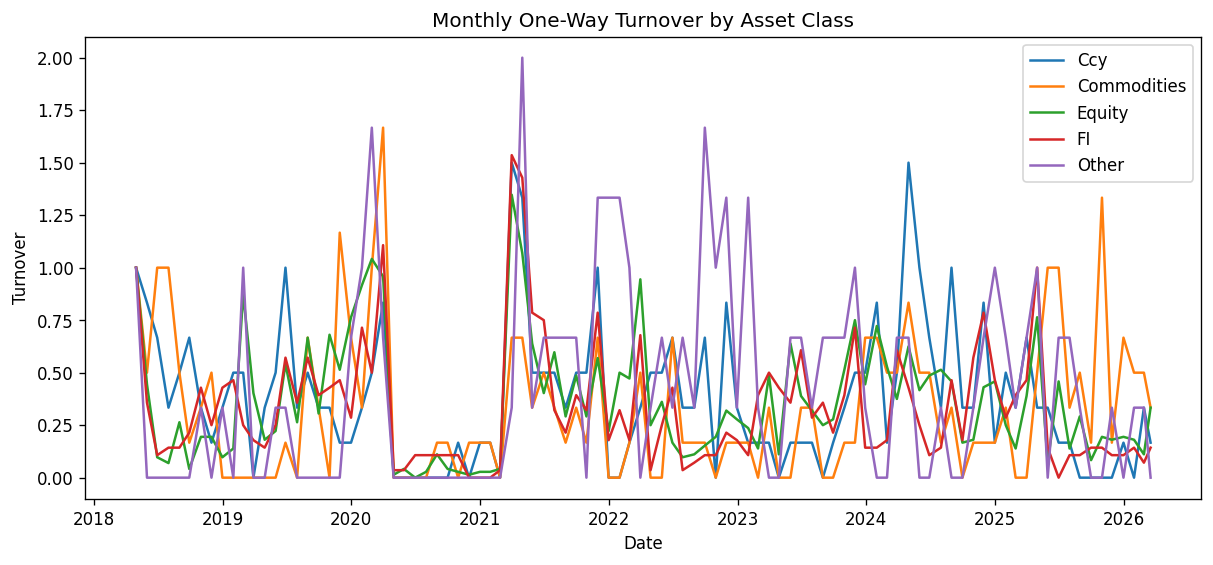

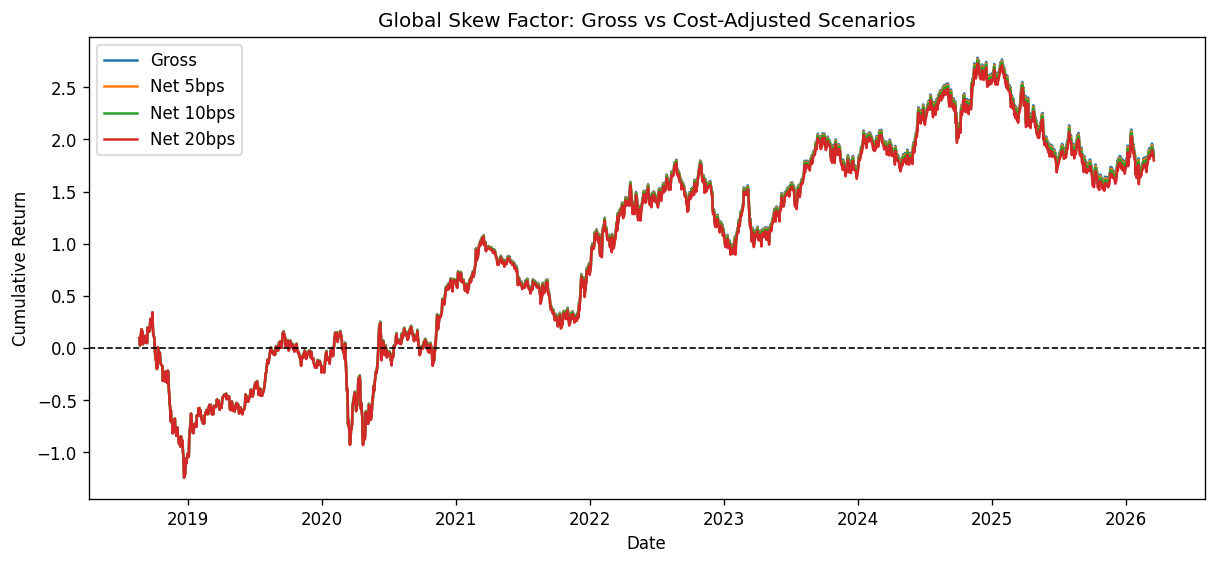

In [14]:
turnover = monthly_turnover(monthly_vals)
display(turnover.groupby('AssetClass', as_index=False)['Turnover'].agg(['mean', 'median', 'max']).reset_index())
plot_turnover_by_class(turnover)

global_turnover = turnover.groupby('Date', as_index=False)['Turnover'].mean()
gcf_cost = gcf.set_index('Date').copy()

for bps in [5, 10, 20]:
    cost = pd.Series(0.0, index=gcf_cost.index)
    tmp = global_turnover.set_index('Date')['Turnover']
    ix = cost.index.intersection(tmp.index)
    cost.loc[ix] = tmp.loc[ix] * (bps / 10000.0)
    gcf_cost[f'Return_net_{bps}bps'] = gcf_cost['Return'] - cost

plt.figure(figsize=(12, 5))
plt.plot(gcf_cost.index, gcf_cost['Return'].cumsum(), label='Gross')
plt.plot(gcf_cost.index, gcf_cost['Return_net_5bps'].cumsum(), label='Net 5bps')
plt.plot(gcf_cost.index, gcf_cost['Return_net_10bps'].cumsum(), label='Net 10bps')
plt.plot(gcf_cost.index, gcf_cost['Return_net_20bps'].cumsum(), label='Net 20bps')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Global Skew Factor: Gross vs Cost-Adjusted Scenarios')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.show()


## 7. Attribution: Market and Style Exposures

Attribution helps answer whether returns come from true skew premia or hidden beta/factor tilts.


In [15]:
results_table = run_asset_class_alpha_beta(asset_portfolios)
display(results_table.round(6))


,Asset Class,alpha,alpha_p,beta,beta_p,R2
0,Ccy,0.000086,0.454294,0.206259,0.000000,0.013462
1,Commodities,0.000288,0.578206,0.054835,0.208343,0.000791
2,Equity,0.000159,0.260649,-0.032029,0.006583,0.003686
3,FI,0.000087,0.229012,-0.022638,0.290281,0.000559
4,Other,-0.000026,0.695972,0.010845,0.024840,0.002515


In [16]:
equity_model, equity_reg_df = run_equity_factor_regression(
    asset_portfolios,
    factor_tickers=FACTOR_TICKERS,
    history_days=HISTORY_DAYS,
)
print(equity_model.summary())


                            OLS Regression Results                            
Dep. Variable:        PortfolioReturn   R-squared:                       0.115
Model:                            OLS   Adj. R-squared:                  0.113
Method:                 Least Squares   F-statistic:                     52.10
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           6.39e-51
Time:                        15:48:59   Log-Likelihood:                 7417.0
No. Observations:                2002   AIC:                        -1.482e+04
Df Residuals:                    1996   BIC:                        -1.479e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       8.363e-05      0.000      0.627      0.5

In [17]:
coef_table = build_coef_table(equity_model)
display(coef_table)


,Coef,StdErr,t,p,CI_L,CI_U
const,0.000084,0.000133,0.626755,0.530892,-0.000178,0.000345
MktReturn,-0.325892,0.023454,-13.894732,0.000000,-0.371889,-0.279894
MTUM,-0.079890,0.022605,-3.534089,0.000418,-0.124222,-0.035557
VTV,0.467167,0.049290,9.477894,0.000000,0.370501,0.563832
VUG,0.129804,0.026785,4.846135,0.000001,0.077275,0.182334
VIG,-0.172322,0.059299,-2.905980,0.003701,-0.288616,-0.056027


## 8. Implementation Validation and Operational Checks

These checks confirm portfolio construction is behaving exactly as intended and remains audit-ready.


In [18]:
sanity = weight_sanity_checks(monthly_vals)
display(sanity.describe(include='all'))

assert (sanity['long_sum'].round(10) == 1.0).all(), 'Long side does not sum to +1 for all periods.'
assert (sanity['short_sum'].round(10) == -1.0).all(), 'Short side does not sum to -1 for all periods.'
assert (sanity['net'].round(10) == 0.0).all(), 'Net exposure is not zero for all periods.'
print('Weight sanity checks passed: long=+1, short=-1, net=0 across all dates/classes.')


,Date,AssetClass,long_sum,short_sum,net
count,480,480,480.000000,480.000000,480.000000
unique,NaN,5,NaN,NaN,NaN
top,NaN,Ccy,NaN,NaN,NaN
freq,NaN,96,NaN,NaN,NaN
mean,2022-04-15 02:15:00,NaN,1.000000,-1.000000,-0.000000
min,2018-04-30 00:00:00,NaN,1.000000,-1.000000,-0.000000
25%,2020-04-22 12:00:00,NaN,1.000000,-1.000000,0.000000
50%,2022-04-14 12:00:00,NaN,1.000000,-1.000000,0.000000
75%,2024-04-05 06:00:00,NaN,1.000000,-1.000000,0.000000
max,2026-03-18 00:00:00,NaN,1.000000,-1.000000,0.000000


Weight sanity checks passed: long=+1, short=-1, net=0 across all dates/classes.


## 9. PM/Trader Interpretation Notes

- The strategy is implemented as a **cross-sectional, class-neutral relative value process**, not a directional market bet.
- The strongest sleeves can dominate global PnL; class-level diagnostics should guide allocation overlays.
- Turnover and cost scenarios should always be reviewed before claiming deployability.
- Attribution confirms whether apparent alpha is independent or mostly explained by market/style exposures.

This notebook is intentionally modular so you can iterate on assumptions (lookback, universe, execution/cost model, scaling choice) with minimal notebook edits.
